Time taken by evolve_step is 0.3772 seconds
Animation saved as ../data/MNIST/vae-o-all-ld-r10/samples/evolution.mp4
Time taken by evolve is 31.1215 seconds
Time taken by visualize is 31.5171 seconds


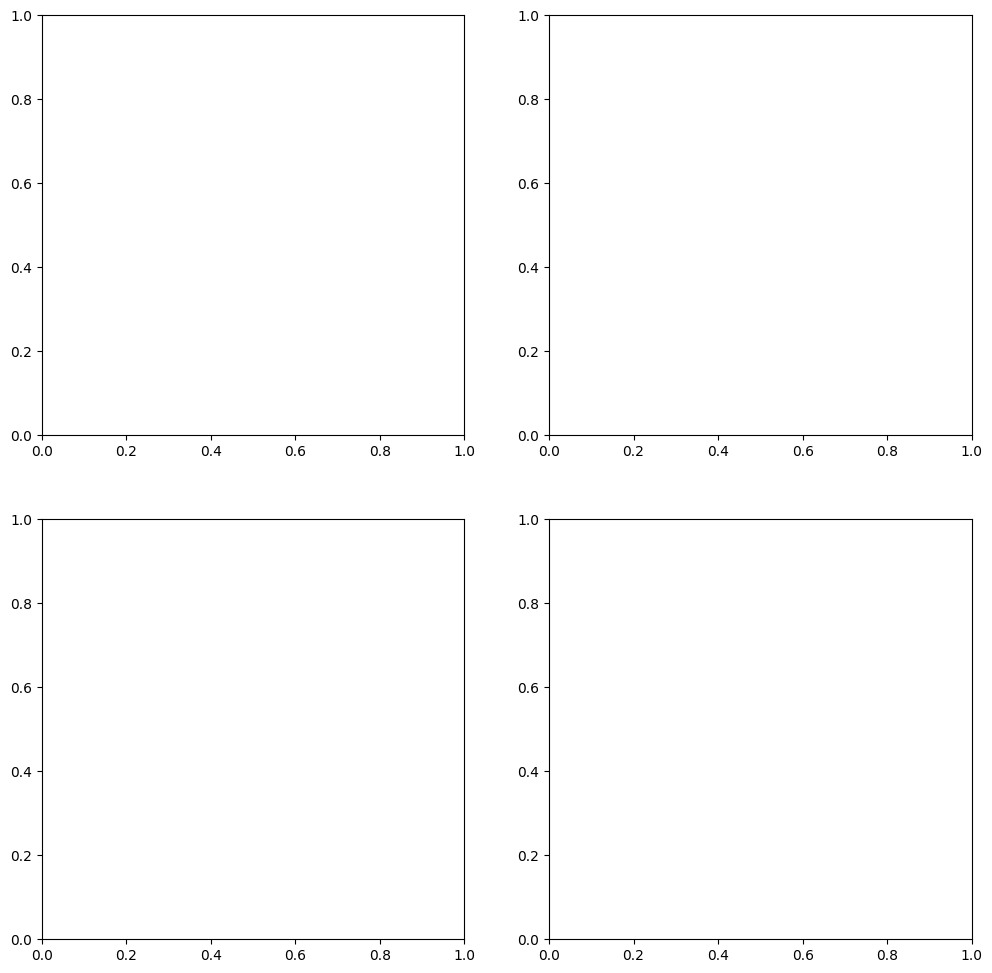

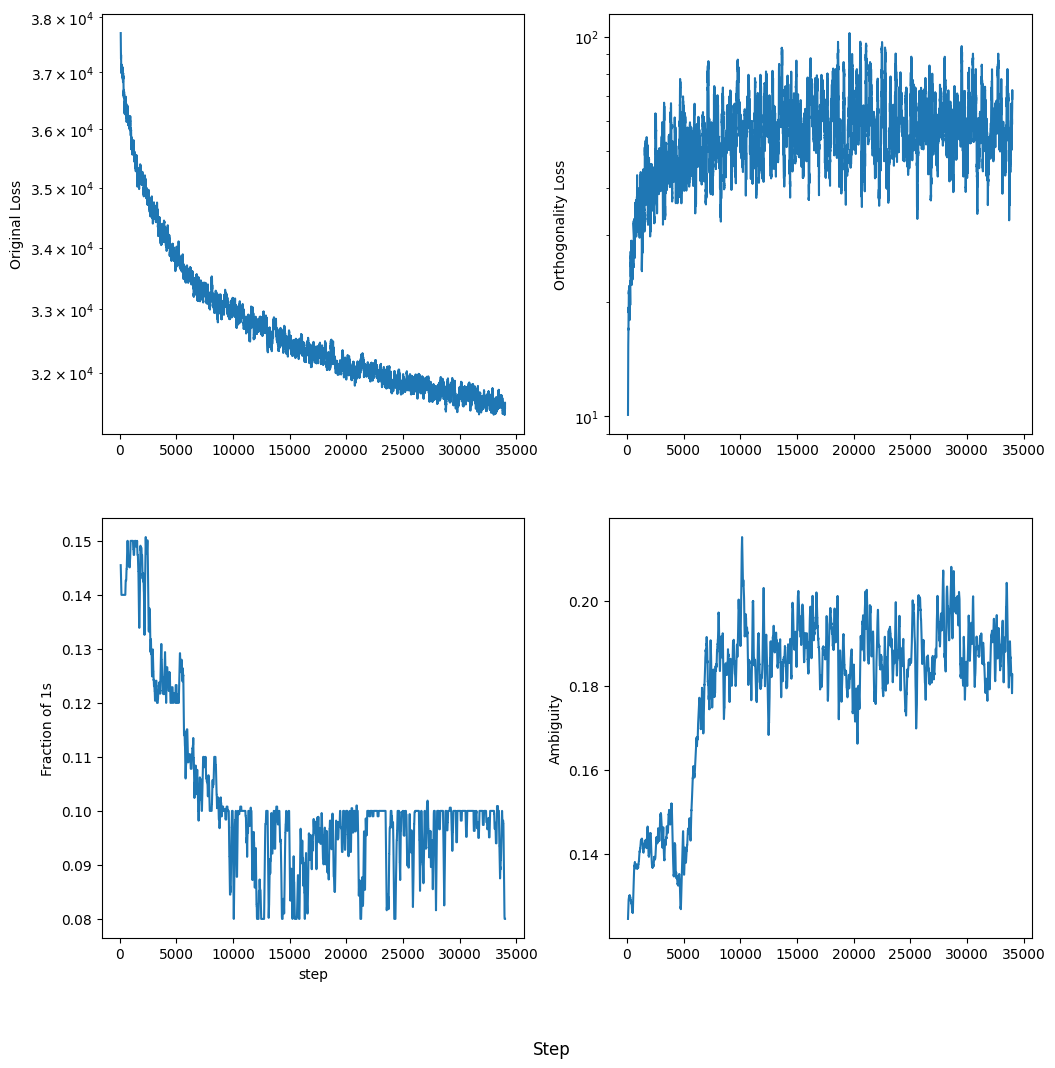

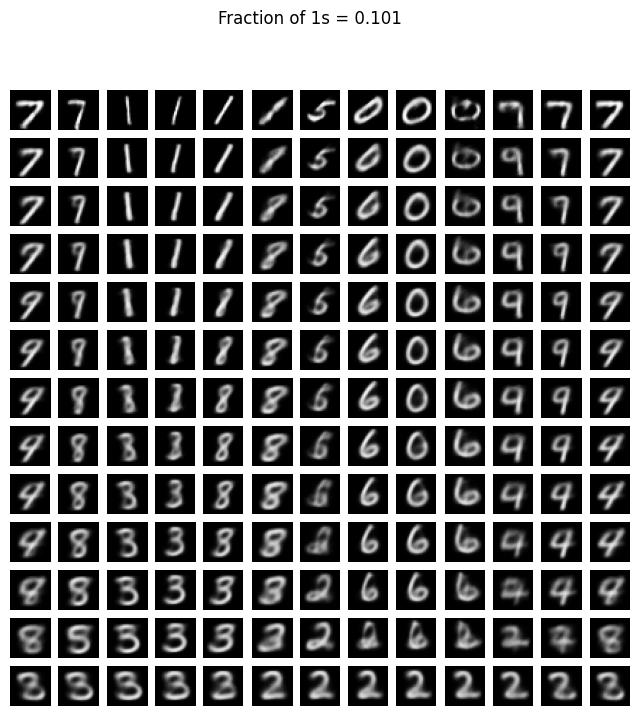

In [15]:
import os, sys, torch
sys.path.append(os.path.abspath('../modules/mnist'))
sys.path.append(os.path.abspath('../modules'))
import vae
import vae_viz as viz
import utility as ut
from torchsummary import summary
import lora


folder = '../data/MNIST/vae'
epochs = 100
batch_size = 100
latent_dim = 2
device = torch.device("cuda" if torch.cuda.is_available() else "mps")



lora_r = 10
net_path_0 = '../data/MNIST/vae/checkpoints/vae_500.pth'
orthogonality_factor = 10.

model = vae.VAE(device=device)
model.load_state_dict(torch.load(net_path_0))
#


expr_folder = f'../data/MNIST/vae-o-all-ld-r{lora_r}'
net_path_1 = f'../data/MNIST/vae-o-all-ld-r{lora_r}/checkpoints/vae_1.pth'
lora_model = vae.LoRA_VAE_Decoder(ut.freeze_all(model), lora_r=lora_r).to(device)
lora_model.load_state_dict(torch.load(net_path_1))
viz.visualize(lora_model, expr_folder, num_samples_animation=169, fps=12, total_frames=200)


# expr_folder = f'../data/MNIST/vae-o-all-long'
# viz.visualize(model, expr_folder, num_samples_animation=169, fps=12, total_frames=200)